In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bacco
import biparallel

In [2]:
basedir = '/home/zennaro/CosmoCodes/Simulations/N768_L256/nenya_N768_output/0.00/'
halo_file = 'groups_081/fof_subhalo_history_tab_orph_wweight_081'
sim = bacco.Simulation(basedir=basedir, halo_file=halo_file)
sim

2026-06-09 19:09:31,129 bacco.sims : Initialising simulation Default
2026-06-09 19:09:31,134 bacco.sims : Loading /home/zennaro/CosmoCodes/Simulations/N768_L256/nenya_N768_output/0.00/groups_081/fof_subhalo_history_tab_orph_wweight_081
2026-06-09 19:09:31,161 bacco.cosmo : Initialising 'Default' cosmology at z=0.00


Simulation(tag='Default', cosmo='Default', box=256.0, a=0.9990212338420196, z=0.001, N=452984832, format='gadget_hdf5', seed=-406168)

In [3]:
ngrid = 64
density_mesh = bacco.statistics.compute_mesh(ngrid=ngrid, box=sim.header['BoxSize'], pos=sim.sdm['pos'], vel=None,
                                             interlacing=True, deposit_method='tsc', folds=1, compensated=True,
                                             zspace=False, cosmology=sim.Cosmology, nthreads=None, twod=False)
density_mesh /= np.mean(density_mesh)
density_mesh -= 1

2026-06-09 19:09:31,195 bacco.sims : Reconstructing sDM
2026-06-09 19:09:31,329 bacco.sims : Reading sDM (single pass): pos, offset, len, vel, ids
2026-06-09 19:09:31,749 bacco.sims : Reading 1945855 items for GroupVel
2026-06-09 19:09:31,895 bacco.sims : Reading 1945855 items for GroupPos
2026-06-09 19:09:32,059 bacco.sims : Done reconstructing sDM
2026-06-09 19:09:32,060 bacco.statistics : Computing tsc mesh with 7077888 objects, ngrid=64, interlacing=True, and nthreads=4


In [4]:
kmin = 2 * np.pi / sim.header['BoxSize']
kmax = np.pi * ngrid / sim.header['BoxSize'] / 2

dlogk = 0.1
kbins_log = np.arange(np.log10(kmin), np.log10(kmax), dlogk)
kbins_edges = 10**kbins_log

print(kbins_edges)
print(kbins_edges.shape)

[0.02454369 0.03089868 0.03889913 0.0489711  0.06165097 0.07761397
 0.0977102  0.12300985 0.15486023 0.19495748 0.24543693 0.30898678
 0.38899131]
(13,)


In [5]:
bp = biparallel.BiParallel(density_mesh, sim.header['BoxSize'])
bp.print_mesh()

density_mesh ndim=3 shape=(64, 64, 64)


In [6]:
my_bisp = bp.compute_bispectrum(kbins_edges)

density_mesh ndim=3 shape=(64, 64, 64)


/home/zennaro/CosmoCodes/biparallel/biparallel/biparallel.py:100: RuntimeWarning: invalid value encountered in divide
  bispectrum = raw_bispectrum / normalization * self.Lbox**6 / self.density_mesh.size**3


In [7]:
my_eff_tri = bp.compute_effective_triangles(kbins_edges)

In [8]:
from bisputils import BaccoBispectrum
bb = BaccoBispectrum(sim)
big_res = bb.compute_bispectrum_BiG(ngrid=ngrid, kmin=kmin, kmax=kmax, dk=dlogk, binning_mode='log', compensated=True)

2026-06-09 19:09:38,978 bacco.statistics : Computing tsc mesh with 7077888 objects, ngrid=64, interlacing=True, and nthreads=4


[CpuDevice(id=0)]
N bins: 12
kbins: [0.02454369 0.03089868 0.03889913 0.0489711  0.06165097 0.07761397
 0.0977102  0.12300985 0.15486023 0.19495748 0.24543693 0.30898678
 0.38899131]
Finished setting members of bispectrumExtractor
Creating k-mesh


/home/zennaro/CosmoCodes/biparallel/bisputils.py:59: RuntimeWarning: divide by zero encountered in divide
  eff_triangles = np.array(Xtract.calculateEffectiveTriangle_slow(mode=mode)).T / norm
/home/zennaro/CosmoCodes/biparallel/bisputils.py:59: RuntimeWarning: invalid value encountered in divide
  eff_triangles = np.array(Xtract.calculateEffectiveTriangle_slow(mode=mode)).T / norm


Doing Fourier Transformation of density field
Doing Bispec calculation


/home/zennaro/CosmoCodes/biparallel/bisputils.py:60: RuntimeWarning: divide by zero encountered in divide
  bkkk = np.array(Xtract.calculateBispectrum_slow(density_grid, mode=mode, filetype=filetype)) / norm * prefactor
/home/zennaro/CosmoCodes/biparallel/bisputils.py:60: RuntimeWarning: invalid value encountered in divide
  bkkk = np.array(Xtract.calculateBispectrum_slow(density_grid, mode=mode, filetype=filetype)) / norm * prefactor


Doing Powerspec normalization calculation
Doing Fourier Transformation of density field
Doing Powerspec calculation


/tmp/ipykernel_1281512/1122884663.py:8: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(trindex, my_bisp / big_res['bispectrum'])


(165,)
(165,)


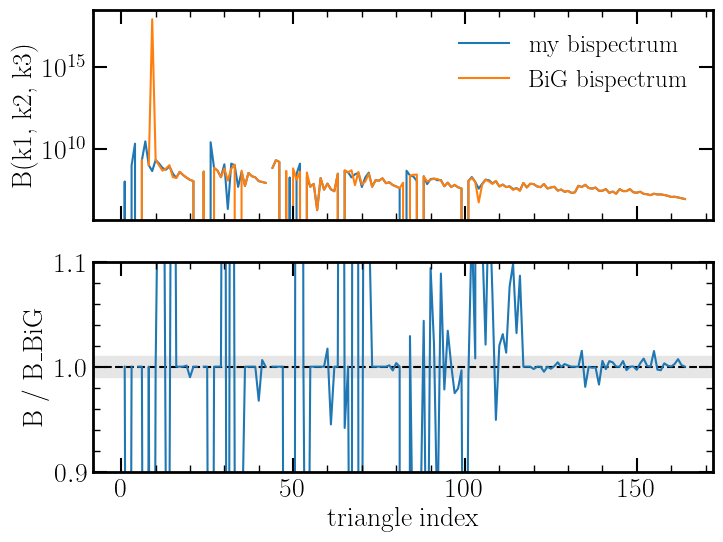

In [12]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

trindex = np.arange(len(my_bisp))
ax[0].semilogy(trindex, my_bisp, label='my bispectrum')
ax[0].semilogy(trindex, big_res['bispectrum'], label='BiG bispectrum')
ax[1].axhspan(0.99, 1.01, color='0.9')
ax[1].axhline(1, color='k', ls='--')
ax[1].plot(trindex, my_bisp / big_res['bispectrum'])
ax[1].set_xlabel('triangle index')
ax[0].set_ylabel('B(k1, k2, k3)')
ax[1].set_ylabel('B / B_BiG ')
ax[0].legend()

ax[1].set_ylim(0.9, 1.1)
print(big_res['bispectrum'].shape)
print(my_bisp.shape)

plt.show()

In [16]:
normalization_array = bp.compute_normalization(kbins_edges)

/tmp/ipykernel_1281512/2711078044.py:7: RuntimeWarning: invalid value encountered in divide
  ax[0].plot(trindex, my_k1_eff / normalization_array / big_k1_eff, label='my k1_eff')
/tmp/ipykernel_1281512/2711078044.py:8: RuntimeWarning: invalid value encountered in divide
  ax[1].plot(trindex, my_k2_eff / normalization_array / big_k2_eff, label='my k2_eff')
/tmp/ipykernel_1281512/2711078044.py:9: RuntimeWarning: invalid value encountered in divide
  ax[2].plot(trindex, my_k3_eff / normalization_array / big_k3_eff, label='my k3_eff')
/tmp/ipykernel_1281512/2711078044.py:9: RuntimeWarning: divide by zero encountered in divide
  ax[2].plot(trindex, my_k3_eff / normalization_array / big_k3_eff, label='my k3_eff')


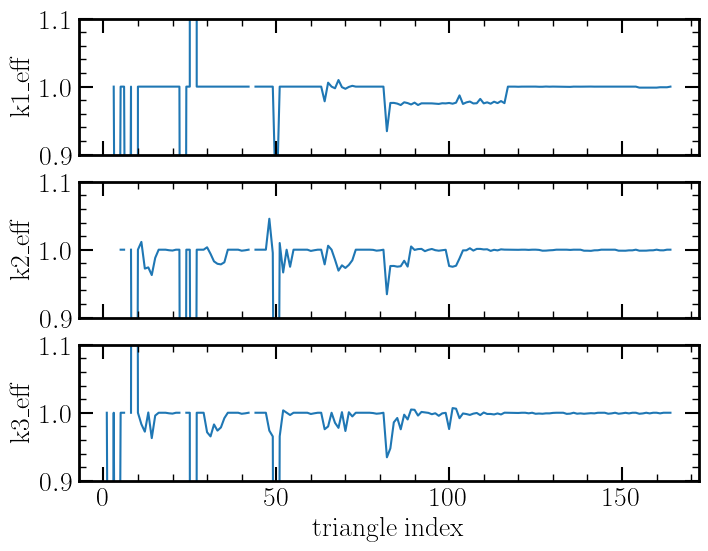

In [18]:
%matplotlib inline

my_k1_eff, my_k2_eff, my_k3_eff = my_eff_tri
big_k1_eff, big_k2_eff, big_k3_eff = big_res['effective_triangles']

fig, ax = plt.subplots(3, 1, sharex=True, figsize=(8, 6))
ax[0].plot(trindex, my_k1_eff / normalization_array / big_k1_eff, label='my k1_eff')
ax[1].plot(trindex, my_k2_eff / normalization_array / big_k2_eff, label='my k2_eff')
ax[2].plot(trindex, my_k3_eff / normalization_array / big_k3_eff, label='my k3_eff')

ax[0].set_ylabel('k1_eff')
ax[1].set_ylabel('k2_eff')
ax[2].set_ylabel('k3_eff')
ax[2].set_xlabel('triangle index')

ax[0].set_ylim(0.9, 1.1)
ax[1].set_ylim(0.9, 1.1)
ax[2].set_ylim(0.9, 1.1)

plt.show()